In [1]:


pip install fmpy matplotlib pandas numpy

   ---------------------------------------- 0.0/6.5 MB ? eta -:--:--
   --- ------------------------------------ 0.5/6.5 MB 6.8 MB/s eta 0:00:01
   ----------------- ---------------------- 2.9/6.5 MB 9.5 MB/s eta 0:00:01
   -------------------------------------- - 6.3/6.5 MB 13.1 MB/s eta 0:00:01
   ---------------------------------------- 6.5/6.5 MB 12.1 MB/s  0:00:00
   ---------------------------------------- 0.0/41.2 MB ? eta -:--:--
   ------ --------------------------------- 6.6/41.2 MB 31.1 MB/s eta 0:00:02
   ------------- -------------------------- 13.6/41.2 MB 33.1 MB/s eta 0:00:01
   ------------------ --------------------- 19.1/41.2 MB 31.2 MB/s eta 0:00:01
   ----------------------- ---------------- 24.6/41.2 MB 29.4 MB/s eta 0:00:01
   ---------------------------- ----------- 29.6/41.2 MB 28.6 MB/s eta 0:00:01
   --------------------------------- ------ 34.6/41.2 MB 27.7 MB/s eta 0:00:01
   -------------------------------------- - 39.8/41.2 MB 27.3 MB/s eta 0:00:01
   ---

In [4]:
from fmpy import simulate_fmu
import pandas as pd

result = simulate_fmu('AGV_Wheels_v2.fmu', stop_time=5.0, output_interval=0.01)
df = pd.DataFrame(result)

print("\nALL VARIABLE NAMES:\n")
for c in df.columns:
    print(c)


ALL VARIABLE NAMES:

time
chassis_joint.phi
chassis_joint.w
left_joint.phi
left_joint.w
Right_joint1.phi


Available columns:
time
chassis_joint.phi
chassis_joint.w
left_joint.phi
left_joint.w
Right_joint1.phi


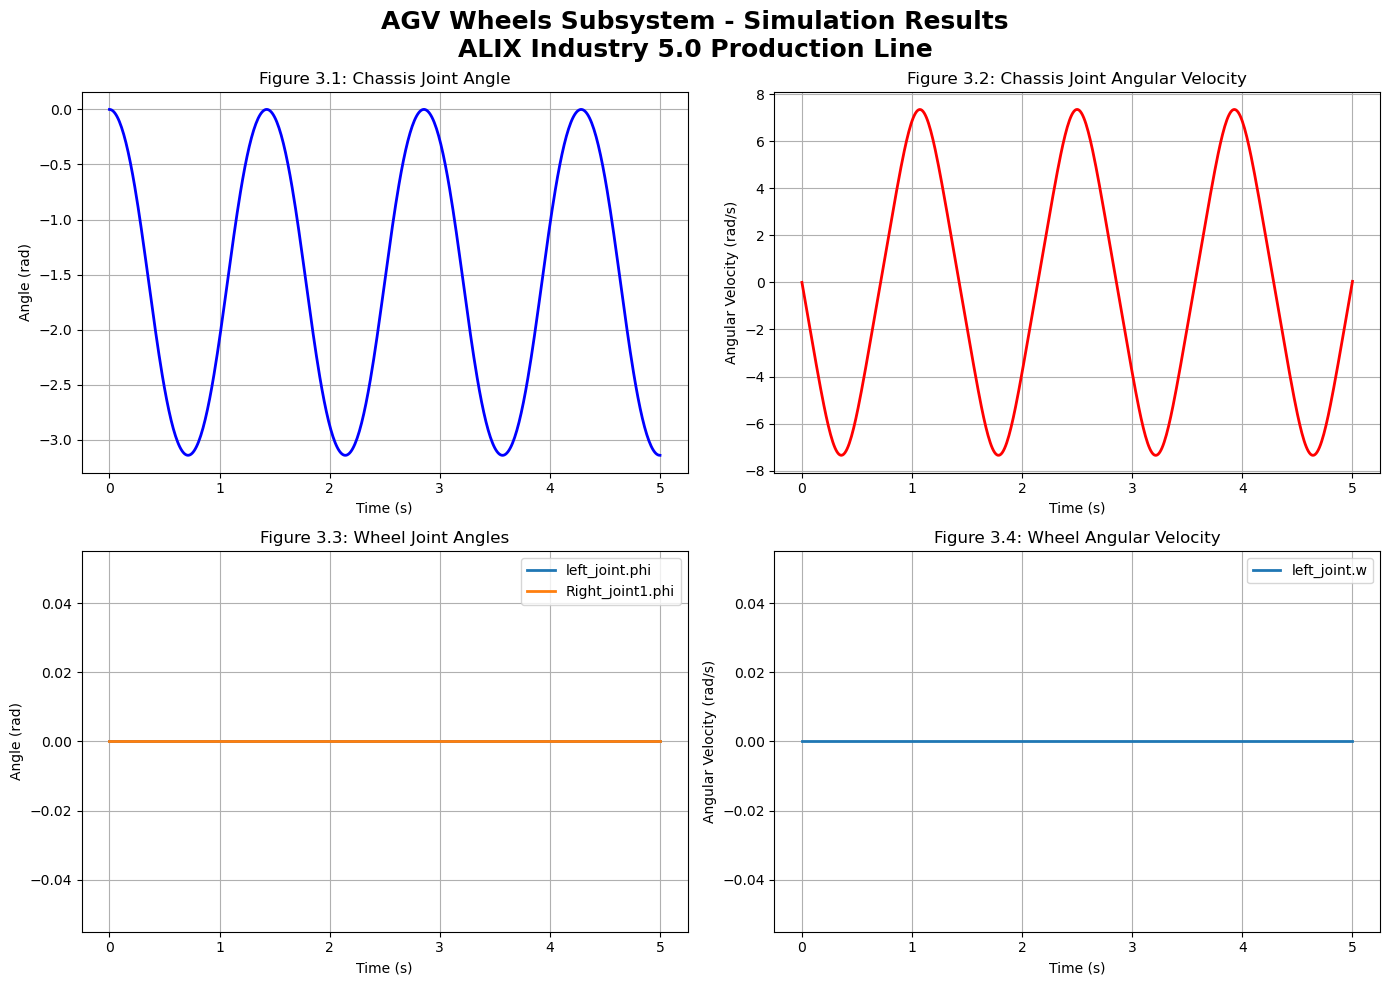


Summary:
chassis_joint.phi min = -3.1417, max = 0.0000
chassis_joint.w min = -7.3460, max = 7.3482
left_joint.phi min = 0.0000, max = 0.0000
left_joint.w min = 0.0000, max = 0.0000


In [5]:
from fmpy import simulate_fmu
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

fmu_file = 'AGV_Wheels_v2.fmu'

# Simulate
result = simulate_fmu(fmu_file, stop_time=5.0, output_interval=0.01)
df = pd.DataFrame(result)

print("Available columns:")
for c in df.columns:
    print(c)

time = df['time']

# Available variables
phi_cols = [c for c in df.columns if '.phi' in c]
w_cols = [c for c in df.columns if c.endswith('.w') or '.w' in c]

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AGV Wheels Subsystem - Simulation Results\nALIX Industry 5.0 Production Line',
             fontsize=18, fontweight='bold')

# Plot 1: Chassis Joint Angle
ax1 = axes[0, 0]
if 'chassis_joint.phi' in df.columns:
    ax1.plot(time, df['chassis_joint.phi'], 'b', linewidth=2)
    ax1.set_title('Figure 3.1: Chassis Joint Angle')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Angle (rad)')
    ax1.grid(True)
else:
    ax1.text(0.5, 0.5, 'chassis_joint.phi not found', ha='center', va='center')
    ax1.set_title('Figure 3.1')

# Plot 2: Chassis Joint Angular Velocity
ax2 = axes[0, 1]
if 'chassis_joint.w' in df.columns:
    ax2.plot(time, df['chassis_joint.w'], 'r', linewidth=2)
    ax2.set_title('Figure 3.2: Chassis Joint Angular Velocity')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Angular Velocity (rad/s)')
    ax2.grid(True)
else:
    ax2.text(0.5, 0.5, 'chassis_joint.w not found', ha='center', va='center')
    ax2.set_title('Figure 3.2')

# Plot 3: Wheel Joint Angles
ax3 = axes[1, 0]
for col in ['left_joint.phi', 'Right_joint1.phi']:
    if col in df.columns:
        ax3.plot(time, df[col], linewidth=2, label=col)
ax3.set_title('Figure 3.3: Wheel Joint Angles')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Angle (rad)')
ax3.legend()
ax3.grid(True)

# Plot 4: Wheel Angular Velocity
ax4 = axes[1, 1]
for col in ['left_joint.w']:
    if col in df.columns:
        ax4.plot(time, df[col], linewidth=2, label=col)
ax4.set_title('Figure 3.4: Wheel Angular Velocity')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Angular Velocity (rad/s)')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.savefig('AGV_results_final.png', dpi=300, bbox_inches='tight')
plt.show()

# Save CSV
df.to_csv('agv_results_final.csv', index=False)

# Print summary
print("\nSummary:")
if 'chassis_joint.phi' in df.columns:
    print(f"chassis_joint.phi min = {df['chassis_joint.phi'].min():.4f}, max = {df['chassis_joint.phi'].max():.4f}")
if 'chassis_joint.w' in df.columns:
    print(f"chassis_joint.w min = {df['chassis_joint.w'].min():.4f}, max = {df['chassis_joint.w'].max():.4f}")
if 'left_joint.phi' in df.columns:
    print(f"left_joint.phi min = {df['left_joint.phi'].min():.4f}, max = {df['left_joint.phi'].max():.4f}")
if 'left_joint.w' in df.columns:
    print(f"left_joint.w min = {df['left_joint.w'].min():.4f}, max = {df['left_joint.w'].max():.4f}")